In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "grid.color": "#333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif",
})

df = pd.read_csv("./data/processed/indian_films_master.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (299, 21)

Columns:
['tmdb_id', 'title', 'original_language', 'language_queried', 'release_date', 'popularity', 'vote_average', 'vote_count', 'director_gender', 'female_leads_top5', 'male_leads_top5', 'total_cast', 'female_in_full_cast', 'budget', 'revenue', 'runtime', 'genres', 'production_companies', 'bechdel_proxy_score', 'bechdel_proxy_pass', 'bechdel_proxy_partial']

Missing values:
tmdb_id                  0
title                    0
original_language        0
language_queried         0
release_date             0
popularity               0
vote_average             0
vote_count               0
director_gender          0
female_leads_top5        0
male_leads_top5          0
total_cast               0
female_in_full_cast      0
budget                   0
revenue                  0
runtime                  0
genres                   0
production_companies     0
bechdel_proxy_score      2
bechdel_proxy_pass       0
bechdel_proxy_partial    0
dtype: int64


In [6]:
# Parse dates
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year
df["decade"] = (df["year"] // 5 * 5).astype("Int64")  # 5-year buckets

# Parse genres (stored as string lists)
df["genres_list"] = df["genres"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if x else "Unknown")

# Clean revenue/budget (0 means missing in TMDB)
df["revenue_clean"] = df["revenue"].replace(0, np.nan)
df["budget_clean"] = df["budget"].replace(0, np.nan)
df["has_boxoffice"] = df["revenue_clean"].notna()

# ROI
df["roi"] = ((df["revenue_clean"] - df["budget_clean"]) / df["budget_clean"]).replace([np.inf, -np.inf], np.nan)

# Female representation ratio in full cast
df["female_cast_ratio"] = df["female_in_full_cast"] / df["total_cast"].replace(0, np.nan)
df["female_lead_ratio"] = df["female_leads_top5"] / 5

# Director gender label
df["director_gender_label"] = df["director_gender"].map({1: "Female", 2: "Male", 0: "Unknown"})

# Language label
df["language_label"] = df["original_language"].map({"hi": "Hindi", "ta": "Tamil", "te": "Telugu"})

print("✓ Features engineered")
print(f"\nFilms with box office data: {df['has_boxoffice'].sum()} / {len(df)}")
print(f"\nProxy score distribution:\n{df['bechdel_proxy_score'].value_counts().sort_index()}")
print(f"\nDirector gender breakdown:\n{df['director_gender_label'].value_counts()}")
print(f"\nLanguage breakdown:\n{df['language_label'].value_counts()}")

✓ Features engineered

Films with box office data: 198 / 299

Proxy score distribution:
bechdel_proxy_score
0.0    123
2.0    163
3.0     11
Name: count, dtype: int64

Director gender breakdown:
director_gender_label
Male       241
Unknown     38
Female      20
Name: count, dtype: int64

Language breakdown:
language_label
Hindi     256
Tamil      28
Telugu     15
Name: count, dtype: int64


In [13]:
# Key stats for write-up
bo = df[df["has_boxoffice"]]

print("=== REVENUE BY PROXY SCORE ===")
print(bo.groupby("bechdel_proxy_score")["revenue_clean"].agg(["median", "mean", "count"]) / 1e6)

print("\n=== FEMALE CAST RATIO BY LANGUAGE ===")
print(df.groupby("language_label")["female_cast_ratio"].mean().round(3))

print("\n=== DIRECTOR GENDER OVER TIME ===")
print(df.groupby("year")["director_gender_label"].value_counts().unstack(fill_value=0))

print("\n=== TOP 10 HIGHEST GROSSING FILMS ===")
print(bo.nlargest(10, "revenue_clean")[["title", "revenue_clean", "bechdel_proxy_score", "female_lead_ratio", "director_gender_label"]])

=== REVENUE BY PROXY SCORE ===
                        median       mean     count
bechdel_proxy_score                                
0.0                  21.000000  35.460488  0.000081
2.0                  18.254285  33.253694  0.000110
3.0                  30.787356  85.433543  0.000007

=== FEMALE CAST RATIO BY LANGUAGE ===
language_label
Hindi     0.243
Tamil     0.246
Telugu    0.259
Name: female_cast_ratio, dtype: float64

=== DIRECTOR GENDER OVER TIME ===
director_gender_label  Female  Male  Unknown
year                                        
2000                        0     3        0
2001                        1     5        0
2002                        0     1        0
2003                        0     5        0
2004                        1     5        1
2005                        0     7        0
2006                        0    10        1
2007                        1    11        0
2008                        0    10        2
2009                        0    11  

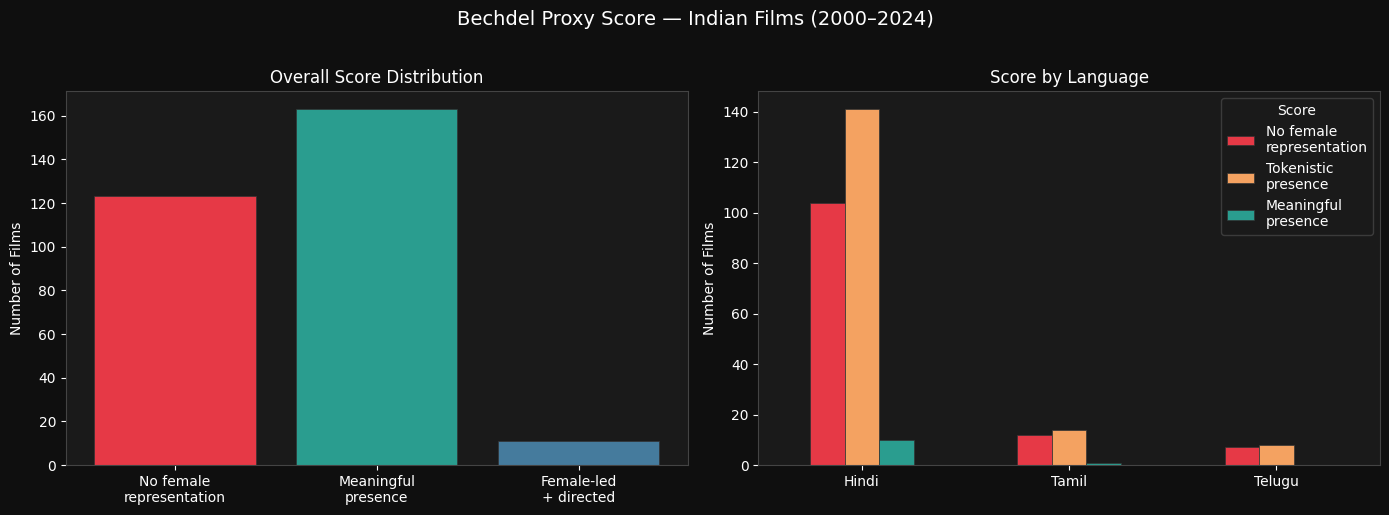

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bechdel Proxy Score — Indian Films (2000–2024)", 
             fontsize=14, color="white", y=1.02)

score_labels = {0: "No female\nrepresentation", 1: "Tokenistic\npresence", 
                2: "Meaningful\npresence", 3: "Female-led\n+ directed"}
colors = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d"]

# Left: overall distribution
counts = df["bechdel_proxy_score"].value_counts().sort_index()
axes[0].bar([score_labels[i] for i in counts.index], counts.values,
            color=[colors[int(i)] for i in counts.index], edgecolor="#333", linewidth=0.5)
axes[0].set_title("Overall Score Distribution", color="white")
axes[0].set_ylabel("Number of Films")

# Right: by language
lang_score = df.groupby(["language_label", "bechdel_proxy_score"]).size().unstack(fill_value=0)
lang_score.plot(kind="bar", ax=axes[1], color=colors, edgecolor="#333", linewidth=0.5)
axes[1].set_title("Score by Language", color="white")
axes[1].set_ylabel("Number of Films")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Score", labels=list(score_labels.values()), 
               facecolor="#1a1a1a", edgecolor="#444", labelcolor="white")

plt.tight_layout()
plt.savefig("../visuals/01_proxy_score_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

Films with box office data: 198


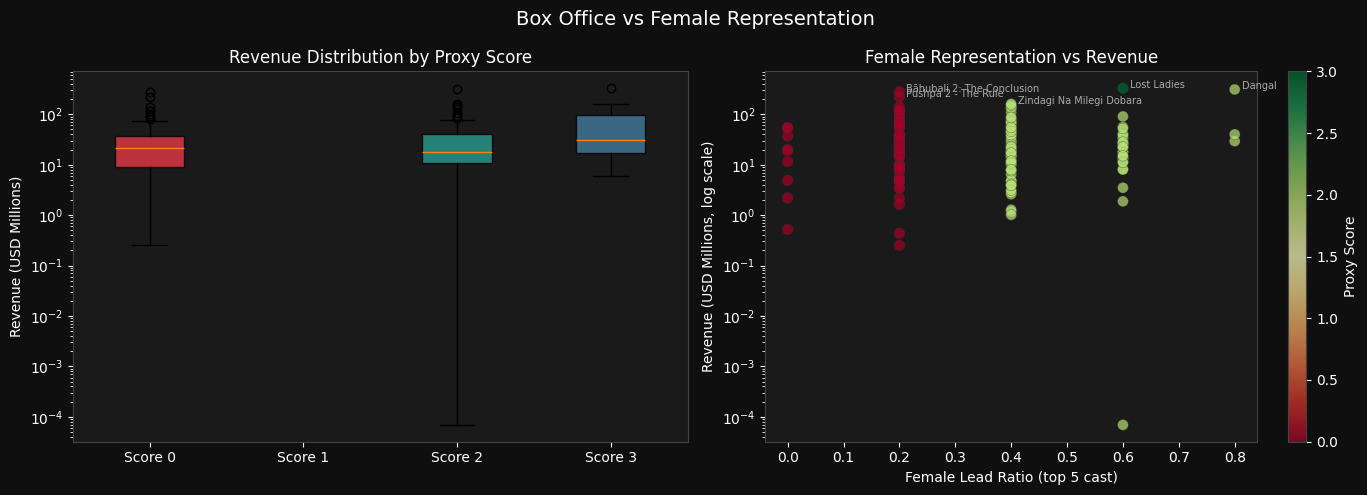

In [9]:
bo_df = df[df["has_boxoffice"]].copy()
print(f"Films with box office data: {len(bo_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Box Office vs Female Representation", fontsize=14, color="white")

# Left: boxplot of revenue by score
score_groups = [bo_df[bo_df["bechdel_proxy_score"] == s]["revenue_clean"].dropna() / 1e6
                for s in [0, 1, 2, 3]]
bp = axes[0].boxplot(score_groups, patch_artist=True, 
                      labels=["Score 0", "Score 1", "Score 2", "Score 3"])
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title("Revenue Distribution by Proxy Score", color="white")
axes[0].set_ylabel("Revenue (USD Millions)")
axes[0].set_yscale("log")

# Right: scatter — female lead ratio vs revenue
sc = axes[1].scatter(bo_df["female_lead_ratio"], bo_df["revenue_clean"] / 1e6,
                     c=bo_df["bechdel_proxy_score"], cmap="RdYlGn",
                     alpha=0.7, s=60, edgecolors="#333", linewidth=0.3)
plt.colorbar(sc, ax=axes[1], label="Proxy Score")
axes[1].set_xlabel("Female Lead Ratio (top 5 cast)")
axes[1].set_ylabel("Revenue (USD Millions, log scale)")
axes[1].set_title("Female Representation vs Revenue", color="white")
axes[1].set_yscale("log")

# Annotate top films
top5 = bo_df.nlargest(5, "revenue_clean")
for _, row in top5.iterrows():
    axes[1].annotate(row["title"], (row["female_lead_ratio"], row["revenue_clean"] / 1e6),
                     fontsize=7, color="#aaa", ha="left",
                     xytext=(5, 0), textcoords="offset points")

plt.tight_layout()
plt.savefig("../visuals/02_revenue_vs_representation.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

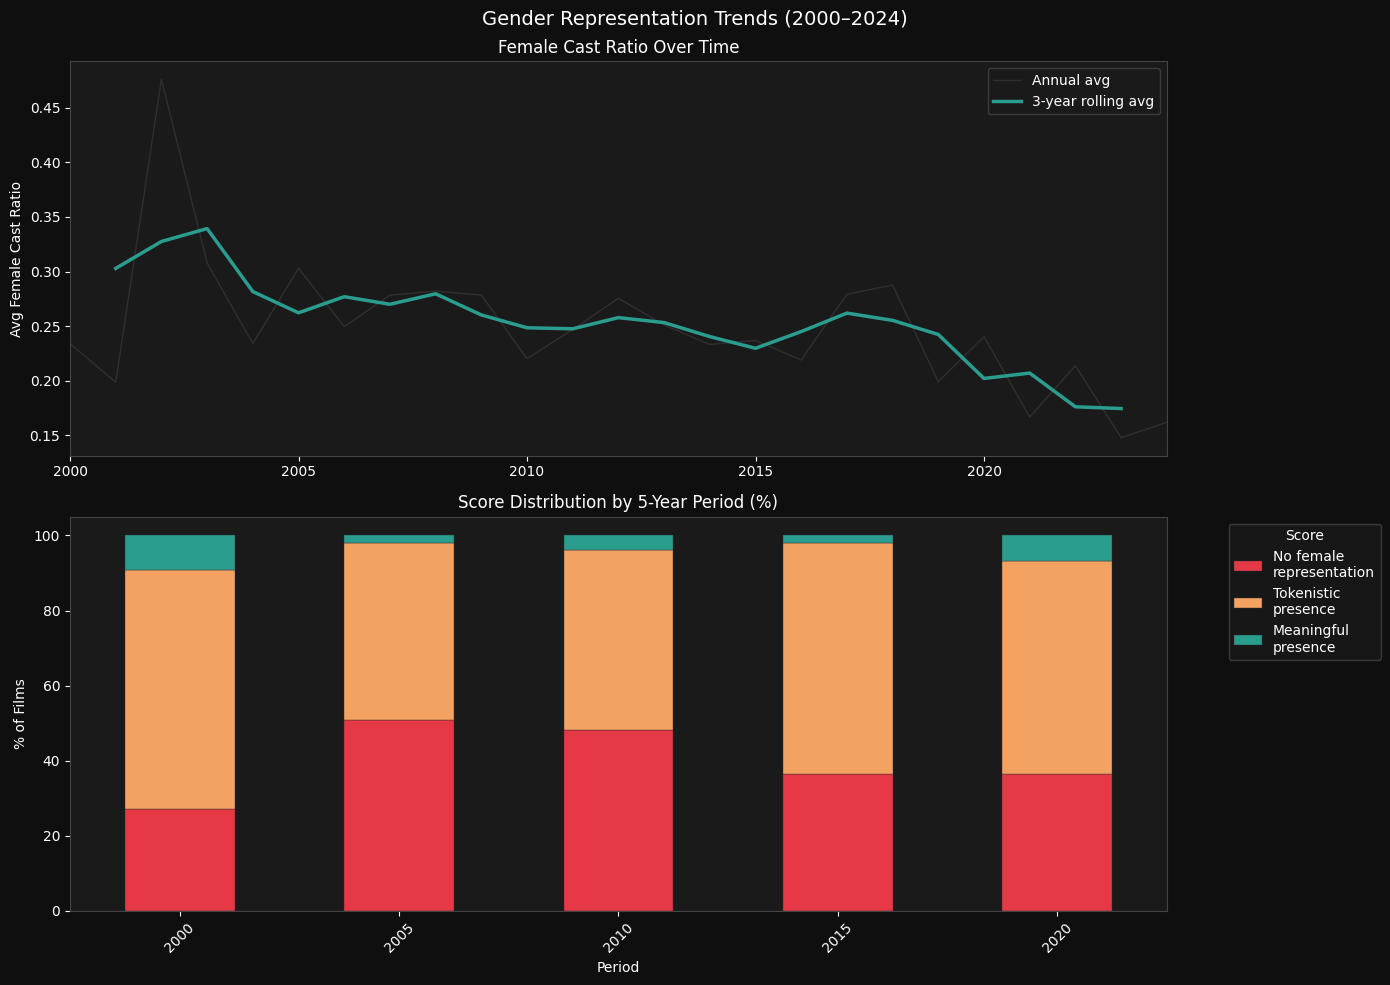

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Gender Representation Trends (2000–2024)", fontsize=14, color="white")

# Top: female cast ratio over time (5-year rolling avg)
yearly = df.groupby("year")["female_cast_ratio"].mean().reset_index()
yearly_smooth = yearly.set_index("year")["female_cast_ratio"].rolling(3, center=True).mean()

axes[0].plot(yearly["year"], yearly["female_cast_ratio"], 
             color="#444", linewidth=1, alpha=0.5, label="Annual avg")
axes[0].plot(yearly_smooth.index, yearly_smooth.values,
             color="#2a9d8f", linewidth=2.5, label="3-year rolling avg")
axes[0].set_title("Female Cast Ratio Over Time", color="white")
axes[0].set_ylabel("Avg Female Cast Ratio")
axes[0].legend(facecolor="#1a1a1a", edgecolor="#444", labelcolor="white")
axes[0].set_xlim(2000, 2024)

# Bottom: stacked bar of proxy scores by 5-year period
period_score = df.groupby(["decade", "bechdel_proxy_score"]).size().unstack(fill_value=0)
period_score_pct = period_score.div(period_score.sum(axis=1), axis=0) * 100
period_score_pct.plot(kind="bar", stacked=True, ax=axes[1], 
                      color=colors, edgecolor="#333", linewidth=0.3)
axes[1].set_title("Score Distribution by 5-Year Period (%)", color="white")
axes[1].set_ylabel("% of Films")
axes[1].set_xlabel("Period")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Score", labels=list(score_labels.values()),
               facecolor="#1a1a1a", edgecolor="#444", labelcolor="white",
               bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig("../visuals/03_trends_over_time.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f")
plt.show()

In [12]:
df.to_csv("./data/processed/indian_films_cleaned.csv", index=False)
print(f"✓ Cleaned dataset saved: {len(df)} films, {df.shape[1]} columns")
print(f"\nKey stats:")
print(f"  Year range: {df['year'].min():.0f} – {df['year'].max():.0f}")
print(f"  Languages: {df['language_label'].value_counts().to_dict()}")
print(f"  Avg female cast ratio: {df['female_cast_ratio'].mean():.1%}")
print(f"  Films with revenue data: {df['has_boxoffice'].sum()}")
print(f"  Proxy pass rate (score=3): {(df['bechdel_proxy_score']==3).mean():.1%}")

✓ Cleaned dataset saved: 299 films, 33 columns

Key stats:
  Year range: 2000 – 2024
  Languages: {'Hindi': 256, 'Tamil': 28, 'Telugu': 15}
  Avg female cast ratio: 24.4%
  Films with revenue data: 198
  Proxy pass rate (score=3): 3.7%
